In [2]:
import importlib
import src.meta_processing as mp
import pandas as pd

gene_expr = pd.read_csv("./data/gene_expression.csv",index_col=0,header=0)
meta = pd.read_csv("data/metadata.csv", usecols=["id", "WHO grade"])
importlib.reload(mp)

#Total
typeIII = mp.typeIII
typeIV = mp.typeIV

#Primary and recurrent
III_primary = mp.III_primary
III_recurrent = (mp.III_recurrent)
IV_primary = (mp.IV_primary)
IV_recurrent = (mp.IV_recurrent)

#III sub
III_prim_PN = (mp.III_prim_PN)
III_prim_Mes = (mp.III_prim_Mes)
III_prim_Prolif = (mp.III_prim_Prolif)

III_rec_PN = (mp.III_rec_PN)
III_rec_Mes = (mp.III_rec_Mes)
III_rec_Prolif = (mp.III_rec_Prolif)


#IV sub
IV_prim_PN = (mp.IV_prim_PN)
IV_prim_Mes = (mp.IV_prim_Mes)
IV_prim_Prolif = (mp.IV_prim_Prolif)

IV_rec_PN = (mp.IV_rec_PN)
IV_rec_Mes = (mp.IV_rec_Mes)
IV_prec_Prolif = (mp.IV_rec_Prolif)

Number of primary type III samples: 21
Number of recurrent type III samples: 3
Number of primary type IV samples: 56
Number of recurrent type IV samples: 20


PRIMARY III
PN: 20
Mes: 1
Prolif: 0


RECURRENT IV
PN: 2
Mes: 1
Prolif: 0


PRIMARY IV
PN: 10
Mes: 22
Prolif: 24


RECURRENT IV
PN: 5
Mes: 11
Prolif: 4
Number of primary type III samples: 21
Number of recurrent type III samples: 3
Number of primary type IV samples: 56
Number of recurrent type IV samples: 20


PRIMARY III
PN: 20
Mes: 1
Prolif: 0


RECURRENT IV
PN: 2
Mes: 1
Prolif: 0


PRIMARY IV
PN: 10
Mes: 22
Prolif: 24


RECURRENT IV
PN: 5
Mes: 11
Prolif: 4


# Perform PCA for III and IV

In [3]:
# Cell 1 — prepare labels and align with expression matrix
labels = (
    meta.set_index("id")["WHO grade"]
    .astype(str)
    .str.extract(r"\b(III|IV)\b", expand=False)
)
labels.index = labels.index.astype(str)

X = gene_expr.T.copy()
X.index = X.index.astype(str)

# keep only shared sample IDs and drop missing labels
common_ids = X.index.intersection(labels.index)
X = X.loc[common_ids]
labels = labels.loc[common_ids]
keep = labels.notna()
X = X.loc[keep]
labels = labels.loc[keep]

print("X shape:", X.shape)
print("labels shape:", labels.shape)
print("aligned:", (X.index == labels.index).all())
print(labels.value_counts())

X shape: (100, 21290)
labels shape: (100,)
aligned: True
WHO grade
IV     76
III    24
Name: count, dtype: int64


Explained variance ratio: [0.09251799 0.06970306]


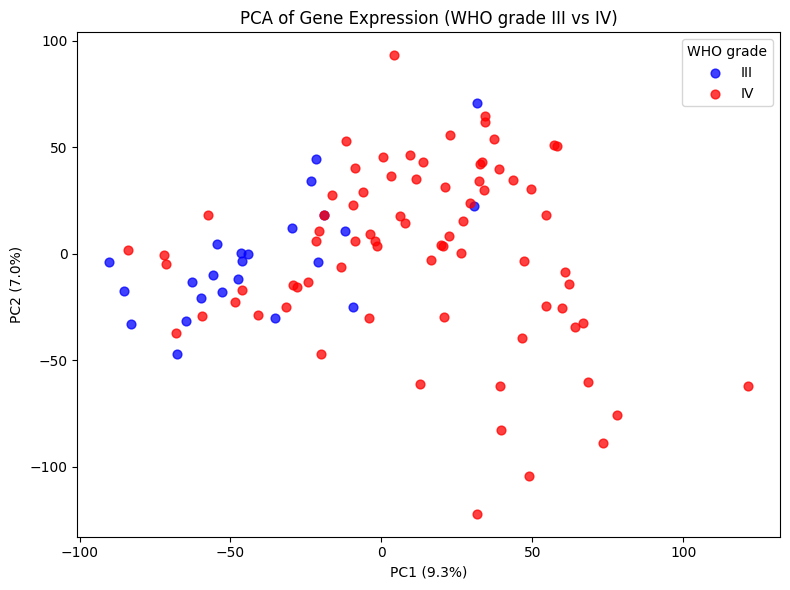

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# PCA scatter with blue/red for III/IV
color_map = {"III": "blue", "IV": "red"}
plt.figure(figsize=(8,6))
for t in sorted(labels.unique()):
    mask = (labels == t).to_numpy()
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=t, color=color_map.get(t, "gray"), alpha=0.75, s=40)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of Gene Expression (WHO grade III vs IV)")
plt.legend(title="WHO grade")
plt.tight_layout()
plt.show()

# Note: No control, just relative to each other

# Volcano plot

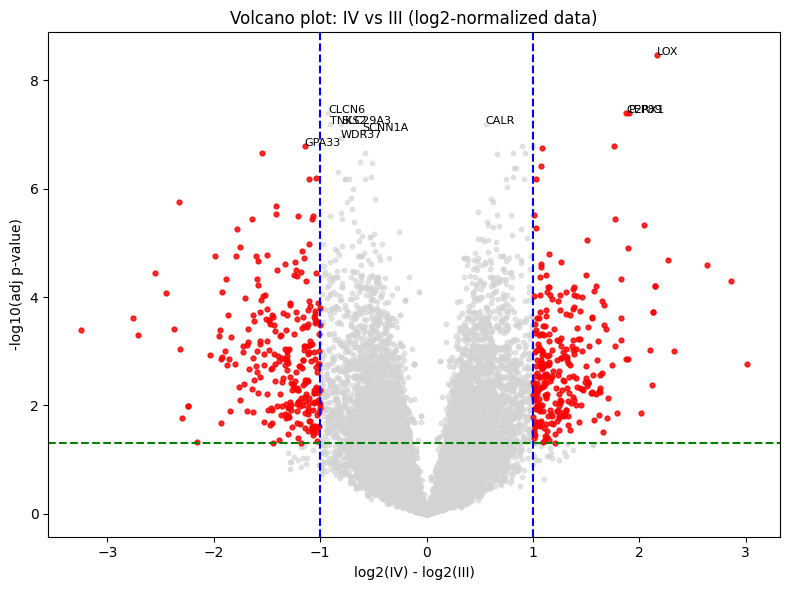

In [5]:
# Volcano plot for log2-normalized X (no log ratio needed)
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# optional FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    _have_multipletests = True
except Exception:
    _have_multipletests = False

groupA, groupB = "III", "IV"
idxA = (labels == groupA)
idxB = (labels == groupB)

X_A = X.loc[idxA]
X_B = X.loc[idxB]

# log2 fold-change as difference of means (since X is log2)
meanA = X_A.mean(axis=0)
meanB = X_B.mean(axis=0)
log2fc = meanB - meanA

# gene-wise t-test (Welch)
pvals = X.apply(lambda col: ttest_ind(col[idxB], col[idxA], equal_var=False, nan_policy="omit").pvalue, axis=0)

# adjust p-values (Benjamini-Hochberg) if available
if _have_multipletests:
    _, p_adj, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
    p_adj = pd.Series(p_adj, index=pvals.index)
else:
    p_adj = pvals.copy()

neg_log10_p = -np.log10(p_adj + 1e-300)

volcano = pd.DataFrame({
    "log2FC": log2fc,
    "pval": pvals,
    "p_adj": p_adj,
    "neg_log10_p": neg_log10_p
})

# plot
plt.figure(figsize=(8,6))
plt.scatter(volcano["log2FC"], volcano["neg_log10_p"], c="lightgray", s=10, alpha=0.6)

# thresholds
fc_thresh = 1.0
p_thresh = 0.05
sig_mask = (volcano["p_adj"] < p_thresh) & (volcano["log2FC"].abs() >= fc_thresh)
plt.scatter(volcano.loc[sig_mask, "log2FC"], volcano.loc[sig_mask, "neg_log10_p"], c="red", s=12, alpha=0.8)

plt.axvline(fc_thresh, color="blue", linestyle="--")
plt.axvline(-fc_thresh, color="blue", linestyle="--")
plt.axhline(-np.log10(p_thresh), color="green", linestyle="--")

plt.xlabel("log2(IV) - log2(III)")
plt.ylabel("-log10(adj p-value)")
plt.title("Volcano plot: IV vs III (log2-normalized data)")
plt.tight_layout()

# annotate top hits
top_hits = volcano.sort_values("p_adj").head(10)
for gene, row in top_hits.iterrows():
    plt.text(row["log2FC"], row["neg_log10_p"], gene, fontsize=8)

plt.show()

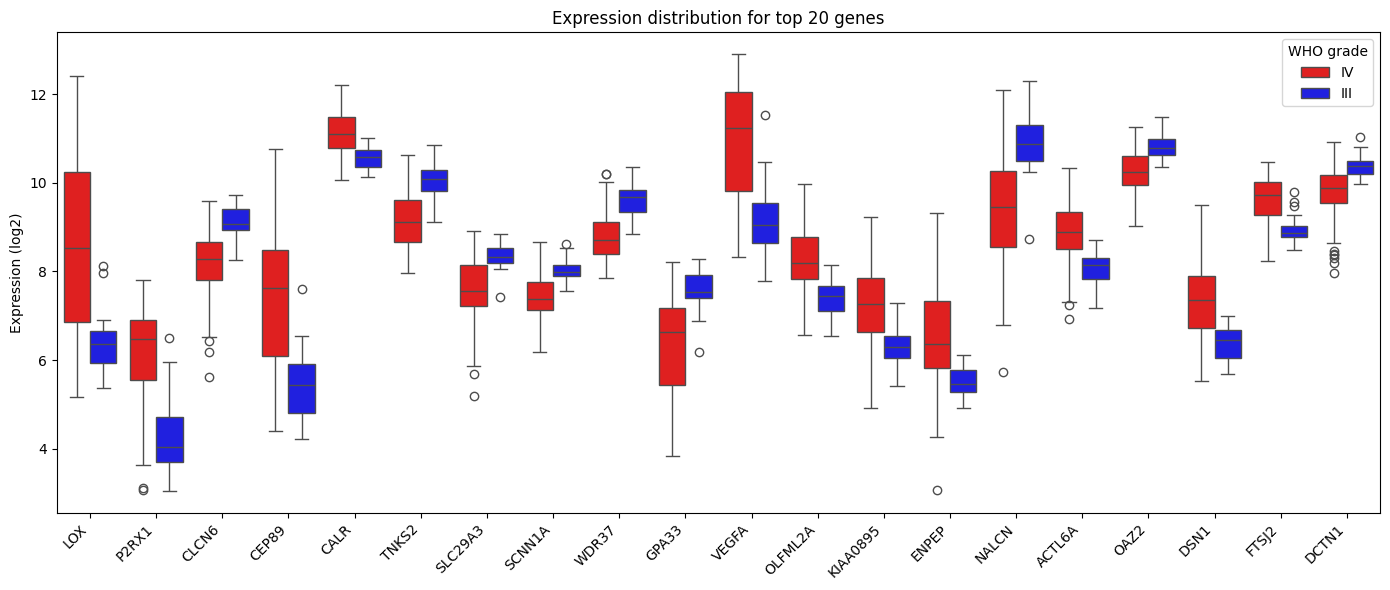

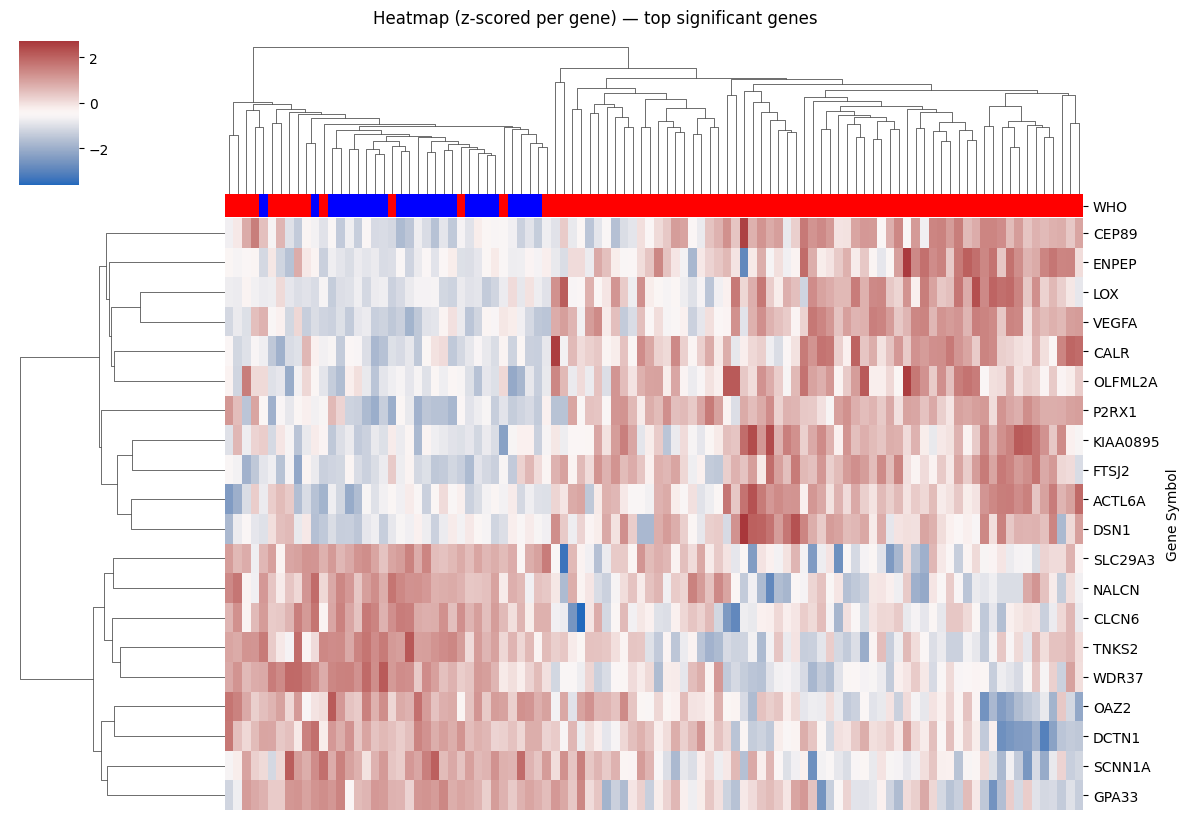

In [7]:
# Boxplots and heatmap selecting top genes from `volcano` (no external top_genes variable)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# choose how many top genes to show
top_n = 20

# ensure `volcano`, `X`, `labels` exist and are aligned
if "volcano" not in globals():
    raise RuntimeError("`volcano` not found — run the volcano cell first")

# pick top genes by adjusted p-value (fallback to pval if p_adj missing)
pcol = "p_adj" if "p_adj" in volcano.columns else "pval"
top_genes = volcano.sort_values(pcol).index[:top_n].tolist()

# Boxplot
labels.name = "WHO"
df_bp = X[top_genes].join(labels).reset_index().melt(id_vars=["index", "WHO"],
                                                     var_name="gene",
                                                     value_name="expr")
plt.figure(figsize=(14,6))
sns.boxplot(x="gene", y="expr", hue="WHO", data=df_bp,
            order=top_genes, palette={"III":"blue","IV":"red"})
plt.xticks(rotation=45, ha="right")
plt.xlabel("")
plt.ylabel("Expression (log2)")
plt.title(f"Expression distribution for top {len(top_genes)} genes")
plt.legend(title="WHO grade")
plt.tight_layout()
plt.show()

# Heatmap / clustermap (z-scored per gene)
data_heat = X[top_genes].T  # genes x samples
data_z = data_heat.subtract(data_heat.mean(axis=1), axis=0).div(data_heat.std(axis=1).replace(0,1), axis=0)

col_colors = labels.map({"III":"blue","IV":"red"}).loc[data_z.columns]

sns.clustermap(data_z, col_colors=col_colors, cmap="vlag", figsize=(12,8),
               xticklabels=False, yticklabels=True)
plt.suptitle("Heatmap (z-scored per gene) — top significant genes", y=1.02)
plt.show()